In [ ]:
# ---------------------------------------------
# 0) Gerekli kütüphaneler
# ---------------------------------------------
import os
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.special import i0
from torch.utils.data import TensorDataset, DataLoader

from scipy.signal import stft, istft

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from diffusers import UNet2DModel, DDPMScheduler


In [ ]:
csv_path = "timeseries_Z.csv"
events_path = "processed_events.csv"


df = pd.read_csv(csv_path)
meta = df.iloc[:, :16]
signals = df.iloc[:, -6980:].to_numpy(dtype=np.float32)

events = pd.read_csv(events_path)
events_dict = dict(zip(events["eq_code"].astype(str), events["azimuth"]))
meta["Azimuth"] = meta["EventID"].astype(str).map(events_dict)/15
meta["RuptureDist_km"] = meta["RuptureDist_km"]
meta["Magnitude"] = meta["Magnitude"]*4
meta["Depth"] = meta["Depth"]*3


# Input vektörü (depth, azimuth, magnitude, dist)
conds = meta[["Depth", "Azimuth", "Magnitude", "RuptureDist_km"]].to_numpy(dtype=np.float32)

# Geçerli veriler (NaN olan azimuth'lar elenir)
valid_mask = ~np.isnan(conds).any(axis=1)
conds = conds[valid_mask]
signals = signals[valid_mask]
print("Valid signal ratio: %", (signals.shape[0]/len(valid_mask))*100)

Valid signal ratio: % 100.0


In [ ]:
# Hedefler: sinyallerin mean ve std'si
means = np.mean(signals, axis=1)* (1e12)
stds = np.std(signals, axis=1)* (1e7)
targets = np.stack([means, stds], axis=1).astype(np.float32)

# Normalize inputlar
scaler = StandardScaler()
conds_scaled = scaler.fit_transform(conds)

In [ ]:
# MLP modeli
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.net(x)

n_train = int(0.9 * len(conds_scaled))
X_train = conds_scaled[:n_train]
X_test = conds_scaled[n_train:]
y_train = targets[:n_train]
y_test = targets[n_train:]


X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


model = MLP()
loss_fn = nn.MSELoss()

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=3e-4)


# Eğitim
for epoch in range(3500):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train)
    loss = loss_fn(preds, y_train)
    loss.backward()
    optimizer.step()

# Test MSE
model.eval()
test_preds = model(X_test)
test_loss = loss_fn(test_preds, y_test)
print("Test MSE:", test_loss.item())


Test MSE: 185.52696228027344


In [ ]:
# ---------------------------------------------
# 1) STFT hesaplama
# ---------------------------------------------


nperseg = 127
noverlap = 72

# STFT hesaplama fonksiyonu
def compute_stft_batch(signal_array, fs=100.0, nperseg=256, noverlap=230):
    out = []
    for s in signal_array:
        _, _, Zxx = stft(s, fs=fs, nperseg=nperseg, noverlap=noverlap)
        out.append(np.abs(Zxx))
    return np.stack(out).astype(np.float32)

stfts = compute_stft_batch(signals, nperseg=nperseg, noverlap=noverlap)


print("Normalized STFT stats:")
# stfts shape: (N, F, T)
means = stfts.mean(axis=(1,2), keepdims=True)   # [N,1,1]
stds  = stfts.std(axis=(1,2), keepdims=True)    # [N,1,1]
stfts = (stfts - means) / stds

# Kontrol
print(np.max(stfts[0]))
print(np.min(stfts[0]))
print(np.mean(stfts[0]))
print(np.std(stfts[0]))

stfts = stfts[:, :, :]
conds = conds[:, :]
print("STFT shape:", stfts.shape)
print("Input shape:", conds.shape)
# ---------------------------------------------


Normalized STFT stats:
28.238708
-0.20793693
-2.2351742e-08
1.0
STFT shape: (1183, 64, 128)
Input shape: (1183, 4)


In [ ]:
class horizontal_embedding(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.freq_bins = cfg.freq_bins  # 64
        self.time_bins = cfg.time_bins  # 128
        self.total_embed_rows = self.freq_bins // 2   # alt yarı = 32
        self.band_height = self.total_embed_rows // 4 # 4 koşul → 8 satır

        assert self.freq_bins == 64
        assert self.time_bins == 128

    def forward(self, stft, cond_vec):
        """
        stft:     [B, 64, 128]
        cond_vec: [B, 4]
        return:   [B, 1, 64, 128]
        """
        B, F, T = stft.shape
        device = stft.device

        out = stft.clone()  # orijinal STFT

        # KOŞUL ŞERİTLERİNİ ALT YARIYA YAZ (F=32:64)
        for i in range(4):
            start = F - (i + 1) * self.band_height     # 56, 48, 40, 32
            end = start + self.band_height             # 64, 56, 48, 40 (ters sırada)
            val = cond_vec[:, i].unsqueeze(-1).unsqueeze(-1)  # [B,1,1]
            val = val.expand(-1, self.band_height, T)         # [B,8,128]
            out[:, start:end, :] = val

        return out.unsqueeze(1)  # [B,1,64,128]


In [ ]:
# ---------------------------------------------
# 3) DataLoader tanımı (train / test)
# ---------------------------------------------

steps = 1000  # diffusion adımı
batch_size = 4
# a) veriyi %90 / %10 oranında ayır
n_total = len(stfts)
n_train = int(n_total * 0.9)

train_signals = torch.from_numpy(stfts[:n_train])
train_conds   = torch.from_numpy(conds[:n_train])
test_signals  = torch.from_numpy(stfts[n_train:])
test_conds    = torch.from_numpy(conds[n_train:])

train_timesteps = torch.randint(0, steps, (n_train, 1))
test_timesteps  = torch.randint(0, steps, (n_total - n_train, 1))


train_ds = TensorDataset(train_signals, train_conds, train_timesteps)
train_loader = DataLoader(train_ds, batch_size=batch_size)


test_ds = TensorDataset(test_signals, test_conds, test_timesteps)
test_loader = DataLoader(test_ds, batch_size=batch_size)



In [ ]:
# ---------------------------------------------
# 4) Diffusers U‑Net + Scheduler + Optimizer
# ---------------------------------------------

# GPU kullanımı
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

# STFT boyutları ve sabit parametreleri buraya koy
FF, T = stfts.shape[1:]  # (freq_bins, time_bins)

CFG = SimpleNamespace(
    freq_bins = FF,
    time_bins = T,
)

# Oldukça küçük bir U-Net modeli, hızlı train olup yeni depremleri kolayca üretecek yapıda.
unet = UNet2DModel(
    sample_size=(CFG.freq_bins, CFG.time_bins),
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(16, 32, 64),
    down_block_types=("DownBlock2D",)*3,
    up_block_types=("UpBlock2D",)*3,
    norm_num_groups=16,
).to(device)




# DDPMScheduler
scheduler = DDPMScheduler(
    num_train_timesteps=steps,
    beta_schedule="linear",
    beta_start=0.1,

)

# Gömme modülü
embedder = horizontal_embedding(CFG).to(device)

CUDA available: True
Device: cuda


In [ ]:

# Diffusion modeli için verilere noise eklemekle görevli fonksiyon.
def get_noisy_input_and_target(x_clean, t_vec, scheduler):
    """
    x_clean : [B, 1, FF, T]
    t_vec   : [B, 1]    timestep (0–steps)
    """
    noise = torch.randn_like(x_clean)
    t = t_vec.squeeze(-1).long().to(x_clean.device)
    x_noisy = scheduler.add_noise(original_samples=x_clean, noise=noise, timesteps=t)
    return x_noisy, noise



# Bir epoch eğitim için gerekli fonksiyon
def train_one_step(x_stft, cond_vec, t_vec, epoch, index, epoch_no):
    unet.train()
    optimizer.zero_grad()
    x_clean = x_stft.to(device).unsqueeze(1)
    x_noisy, noise = get_noisy_input_and_target(x_clean, t_vec, scheduler)

    x_in = embedder(x_noisy.squeeze(1), cond_vec.to(device))

    t_input = t_vec.squeeze(-1).long().to(device)
    out = unet(sample=x_in, timestep=t_input).sample

    # her epoch_no. epoch'ta görselleştir
        # her epoch_no. epoch'ta görselleştir
    if epoch % epoch_no == 0 and index == 0:
        for i in range(1):
            truth = x_clean[i, 0].detach().cpu().numpy()
            noised = x_in[i, 0].detach().cpu().numpy()
            pred = out[i, 0].detach().cpu().numpy()

            fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

            axs[0].imshow(truth, aspect='auto', origin='lower', cmap='viridis')
            axs[0].set_title("Gerçek STFT")
            fig.colorbar(axs[0].images[0], ax=axs[0], fraction=0.046)

            axs[1].imshow(noised, aspect='auto', origin='lower', cmap='viridis')
            axs[1].set_title("Gürültülü STFT (input + cond)")
            fig.colorbar(axs[1].images[0], ax=axs[1], fraction=0.046)

            axs[2].imshow(pred, aspect='auto', origin='lower', cmap='viridis')
            axs[2].set_title("Modelin Ürettiği STFT")
            fig.colorbar(axs[2].images[0], ax=axs[2], fraction=0.046)

            for ax in axs:
                ax.set_xlabel("Time")
                ax.set_ylabel("Frequency")

            plt.tight_layout()
            plt.show()

    loss = F.mse_loss(out, x_clean)
    loss.backward()
    optimizer.step()
    return loss.item()

# Test verileri üzerinde prediction yaparak modelin ne kadar iyi çalıştığını ölçen fonksiyon, (Ayrıca görselleştirme de sağlıyor)
def eval_step(x_stft, cond_vec, t_vec, plot_example=False):
    unet.eval()
    with torch.no_grad():
        x_stft = x_stft.to(device)                 # [B,F,T]
        cond_vec = cond_vec.to(device)             # [B,4]
        t_vec = t_vec.to(device).squeeze(-1).long()

        # Gürültü STFT'e eklenir (embedding'den önce!!!)
        x_noisy, _ = get_noisy_input_and_target(x_stft.unsqueeze(1), t_vec.unsqueeze(1), scheduler)  # [B,1,F,T]
        x_input = embedder(x_noisy.squeeze(1), cond_vec)  # [B,1,F,T]

        out = unet(sample=x_input, timestep=t_vec).sample  # [B,1,F,T]
        loss = F.mse_loss(out.squeeze(1), x_stft)

        if plot_example:
          idx = 0
          pred = out[idx, 0].detach().cpu().numpy()
          truth = x_stft[idx].detach().cpu().numpy()
          noised = x_input[idx, 0].detach().cpu().numpy()

          fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

          axs[0].imshow(truth, aspect='auto', origin='lower', cmap='viridis')
          axs[0].set_title("Gerçek STFT")
          fig.colorbar(axs[0].images[0], ax=axs[0], fraction=0.046)

          axs[1].imshow(noised, aspect='auto', origin='lower', cmap='viridis')
          axs[1].set_title("Gürültülü STFT")
          fig.colorbar(axs[1].images[0], ax=axs[1], fraction=0.046)

          axs[2].imshow(pred, aspect='auto', origin='lower', cmap='viridis')
          axs[2].set_title("Modelin Ürettiği STFT")
          fig.colorbar(axs[2].images[0], ax=axs[2], fraction=0.046)

          for ax in axs:
              ax.set_xlabel("Time")
              ax.set_ylabel("Frequency")

          plt.tight_layout()
          plt.show()


    return loss.item()

avg_test_loss = 999

In [ ]:
checkpoint = torch.load("horizontal_model.pth", map_location=device)
unet.load_state_dict(checkpoint['unet'])

unet.eval()



UNet2DModel(
  (conv_in): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=16, out_features=64, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=64, out_features=64, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(16, 16, eps=1e-05, affine=True)
          (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=64, out_features=16, bias=True)
          (norm2): GroupNorm(16, 16, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(16, 16, kernel_

In [ ]:
# --------------------------------------------------
# 1) Geri dönüş – STFT → time-domain
# --------------------------------------------------
def inverse_stft_batch(mag_batch, fs=100.0, nperseg=127, noverlap=72, orig_len=6980):
    """
    STFT magnitüdlerinden zaman domeni sinyali üretir.
    • mag_batch: [B, F, T] – full STFT magnitüd (kesilmemiş!)
    • return:    [B, orig_len]
    """
    B, F, T = mag_batch.shape
    signals = []

    for i in range(B):
        mag = mag_batch[i]

        # Rastgele faz eklenmiş kompleks STFT
        phase = np.exp(1j * 2 * np.pi * np.random.rand(F, T)).astype(np.complex64)
        complex_spec = mag.astype(np.float32) * phase

        # Geri dönüş
        _, signal = istft(complex_spec, fs=fs, nperseg=nperseg, noverlap=noverlap, input_onesided=True)

        # Kırpma
        signal = signal[:orig_len] if len(signal) > orig_len else np.pad(signal, (0, orig_len - len(signal)))
        signals.append(signal.astype(np.float32))

    return np.stack(signals)

# --------------------------------------------------
# 2) Test ya da eğitilmiş olduğu train verileri için depth, azimuth, magnitude, dist bilgilerini kullanarak potansiyel deprem sinyalini
# üreten ve gerçek veri ile bu üretilmiş veriyi karşılaştırmayı sağlayan bir fonksiyon.
# --------------------------------------------------
def test_model(unet, embedder, scheduler, stft_batch, cond_batch, t_batch,
               nperseg=127, noverlap=72, orig_len=6980):
    """
    Modelin denoising başarımını STFT ve time-domain karşılaştırmasıyla test eder.
    """
    unet.eval()
    stft_batch = stft_batch.to(device)
    cond_batch = cond_batch.to(device)
    t_batch = t_batch.to(device).squeeze(-1).long()

    with torch.no_grad():
        x_noisy, _ = get_noisy_input_and_target(stft_batch, t_batch.unsqueeze(1), scheduler)
        x_embedded = embedder(x_noisy, cond_batch)
        denoised = unet(sample=x_embedded, timestep=t_batch).sample


    real_np = stft_batch.cpu().numpy()
    denoised_np = denoised.squeeze(1).cpu().numpy()

    # STFT → time-domain
    real_time = inverse_stft_batch(real_np, nperseg=nperseg, noverlap=noverlap, orig_len=orig_len)
    den_time  = inverse_stft_batch(denoised_np, nperseg=nperseg, noverlap=noverlap, orig_len=orig_len)

    # Görsel karşılaştırma
    for i in range(stft_batch.shape[0]):
        # Time-domain çizim
        plt.figure(figsize=(10, 2))
        plt.plot(real_time[i], label="Gerçek", alpha=0.6)
        plt.plot(den_time[i], label="Üretilen", alpha=0.8)
        plt.title(f"Zaman Domeni Karşılaştırması #{i}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # STFT çizim
        fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
        titles = ["Gerçek STFT", "Gürültülü", "Denoised"]
        datas  = [real_np[i], x_embedded[i, 0].cpu().numpy(), denoised_np[i]]
        for ax, data, title in zip(axs, datas, titles):
            im = ax.imshow(data, aspect='auto', origin='lower', cmap='viridis')
            ax.set_title(title)
            fig.colorbar(im, ax=ax, fraction=0.04)
        plt.tight_layout()
        plt.show()


time_step_test = torch.full((1200, 1), 999, dtype=torch.long)

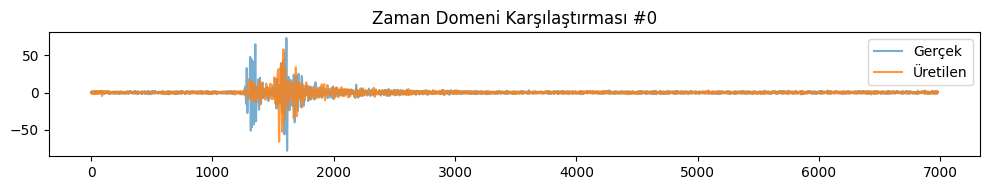

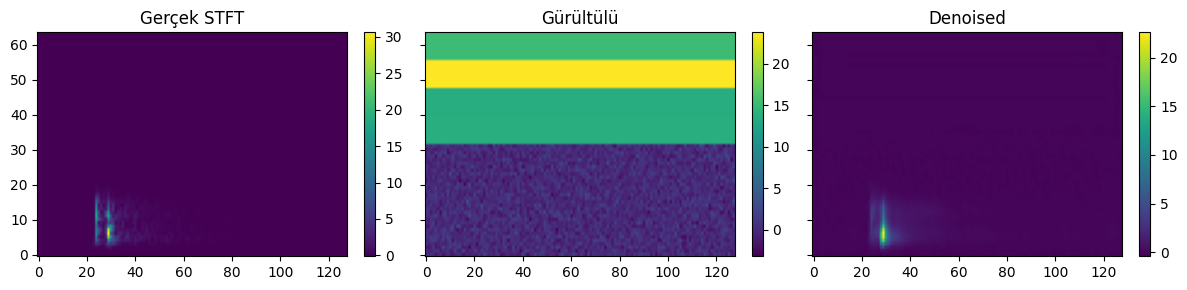

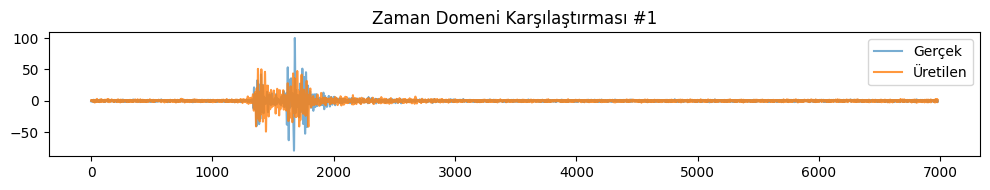

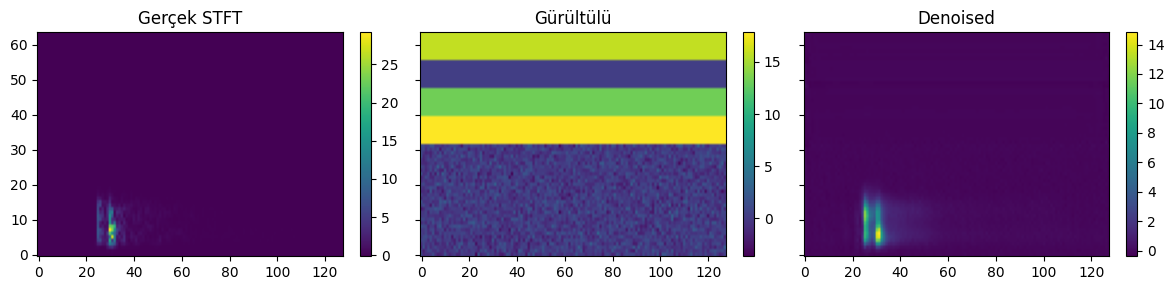

In [ ]:
test_model(unet, embedder, scheduler, test_signals[:2], test_conds[:2], time_step_test[:2], nperseg=nperseg, noverlap=noverlap)

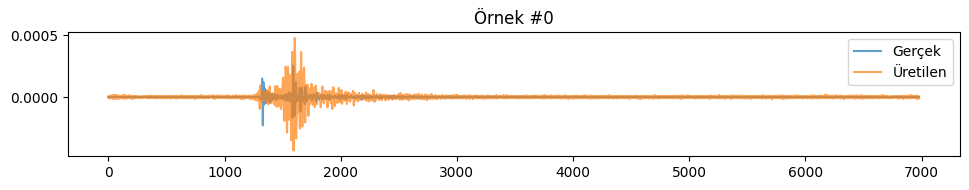

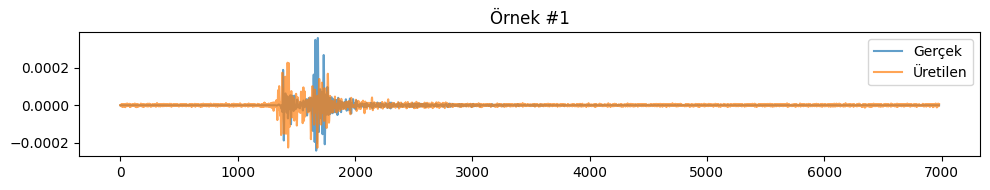

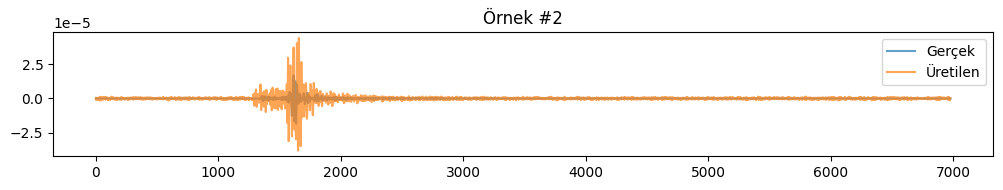

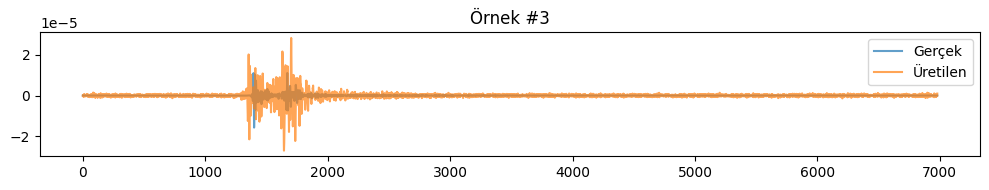

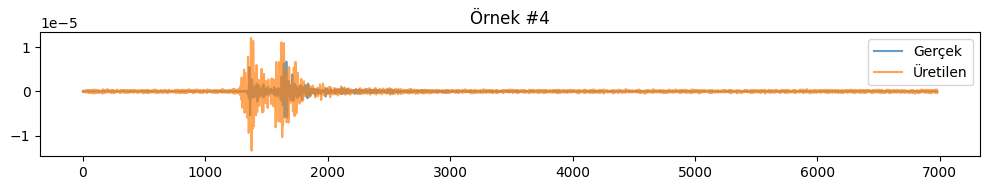

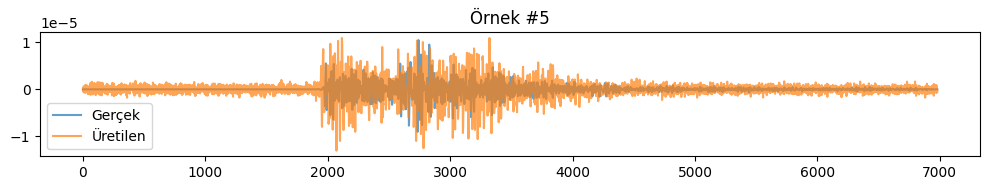

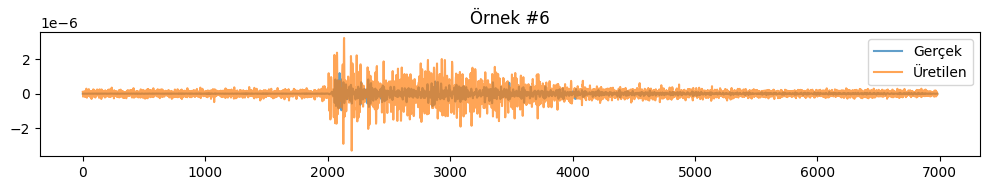

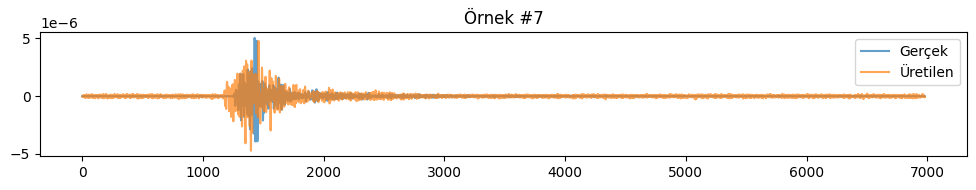

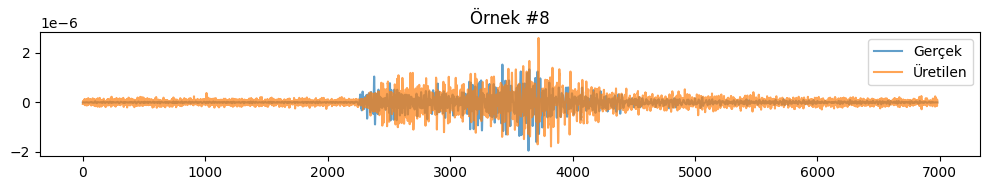

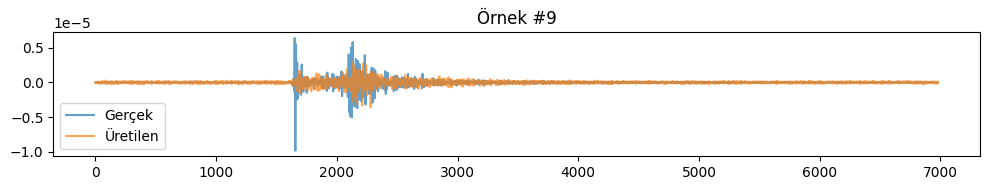

In [ ]:
# --------------------------------------------------------
#  Diffusion + MLP  ─ test verisi entegrasyonu
# --------------------------------------------------------
import torch, numpy as np, matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet.eval().to(device)
model.eval().to(device)

single_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

def sample_stft(cond_vec, scheduler, nperseg, noverlap, orig_len=6980):
    t_batch = torch.full((1,), 999, dtype=torch.long, device=device)
    stft    = torch.zeros((1, 64, 128), device=device)

    with torch.no_grad():
        x_noisy, _ = get_noisy_input_and_target(stft, t_batch.unsqueeze(1), scheduler)
        x_embedded = embedder(x_noisy, cond_vec.to(device))
        denoised   = unet(sample=x_embedded, timestep=t_batch).sample

    sig_norm = inverse_stft_batch(denoised.squeeze(1).cpu().numpy(),
                                  nperseg=nperseg,
                                  noverlap=noverlap,
                                  orig_len=orig_len)[0]
    return sig_norm

# --------------------------------------------------------

for idx, (_stft_dummy, cond_raw, _) in enumerate(single_loader):
    cond_raw = cond_raw.float()

    # 1) Diffusion çıkışı (normalize sinyal)
    sig_norm = sample_stft(cond_raw, scheduler, nperseg, noverlap)

    # 2) MLP çıkışı (μ, σ)
    cond_scaled = torch.tensor(scaler.transform(cond_raw), dtype=torch.float32).to(device)
    with torch.no_grad():
        mean_pred, std_pred = model(cond_scaled).cpu().numpy()[0]

    mean_pred, std_pred = mean_pred * 1e-12, std_pred* 5e-8

    # 3) Denormalizasyon
    sig_hat  = sig_norm * std_pred + mean_pred
    sig_true = signals[n_train + idx]

    # 4) Plot
    plt.figure(figsize=(10, 2))
    plt.plot(sig_true, label="Gerçek",  alpha=0.7)
    plt.plot(sig_hat,  label="Üretilen", alpha=0.7)
    plt.title(f"Örnek #{idx}")
    plt.legend(); plt.tight_layout(); plt.show()

    if idx == 9:
        break


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Möbius transformation
def mobius_transform(z):
    return (2*z - 1j) / (z + 2j)

# Generate random points in the right half-plane
np.random.seed(42)  # for reproducibility
num_points = 1000000

# Generate real parts (Re(z) > 0) and imaginary parts
real_parts = np.random.uniform(0, 10, num_points)  # 0 to 5 for Re(z)
imag_parts = np.random.uniform(-10, 10, num_points)  # -5 to 5 for Im(z)
z_points = real_parts + 1j * imag_parts

# Apply the transformation
w_points = mobius_transform(z_points)

# Plot the results
plt.figure(figsize=(12, 6))

# Plot original points (z-plane)
plt.subplot(1, 2, 1)
plt.scatter(real_parts, imag_parts, s=1, alpha=0.5, color='blue')
plt.axvline(x=0, color='red', linestyle='--')  # imaginary axis
plt.title('Original Points (z-plane)\nRe(z) > 0')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.grid(True)
plt.xlim(-1, 6)
plt.ylim(-6, 6)

# Plot transformed points (w-plane)
plt.subplot(1, 2, 2)
plt.scatter(w_points.real, w_points.imag, s=1, alpha=0.5, color='green')
plt.title('Transformed Points (w-plane)')
plt.xlabel('Re(w)')
plt.ylabel('Im(w)')
plt.grid(True)


plt.tight_layout()
plt.show()